# Clasificación automática de PQRS con NLP: bag-of-words y comparación de modelos

- Objetivo: clasificar automáticamente peticiones, quejas, reclamos y solicitudes (PQRS) de ciudadanos por tipo de solicitud, a partir del texto libre del mensaje.
- Caso de uso: enrutar cada PQRS al área correcta sin depender solo de un humano leyendo uno por uno, algo especialmente valioso cuando los tiempos de respuesta son cortos por norma.
- **Nota importante:** el dataset de este notebook es sintético, generado para fines demostrativos. No corresponde a ningún proyecto o cliente real.
- Artículo completo, con el razonamiento detrás de cada decisión: [fuzzyfrog.ai/es/ai-lab/proyectos/gobierno/clasificacion-automatica-pqrs-nlp-bag-of-words](https://fuzzyfrog.ai/es/ai-lab/proyectos/gobierno/clasificacion-automatica-pqrs-nlp-bag-of-words/)


## Diagrama del pipeline

- **Entrada:** texto libre del mensaje de PQRS, sin estructura fija.
- **Limpieza:** remover caracteres especiales, minúsculas, lematización, remoción de stopwords.
- **Vectorización:** bag-of-words (CountVectorizer) sobre el texto limpio.
- **Benchmarking:** 5 modelos de clasificación comparados con validación cruzada.
- **Salida:** tipo de solicitud predicho, para enrutar automáticamente el mensaje.


## Carga de datos

- El dataset tiene un tamaño reducido a propósito: es la realidad de muchos proyectos de NLP aplicado en organizaciones pequeñas o áreas específicas, no siempre hay miles de ejemplos etiquetados disponibles.
- Cada fila es un mensaje de texto libre con su categoría de solicitud ya etiquetada manualmente.


In [1]:
# Instalar dependencias (Colab)
!pip install -q spacy wordcloud
!python -m spacy download es_core_news_sm -q


error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import spacy
from wordcloud import WordCloud

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

np.random.seed(42)


In [3]:
# Dataset sintetico de demostracion (estructura y escala reales, contenido ficticio)
data = pd.read_csv("dataset/pqrs_sintetico.csv")
print(f"Total de mensajes: {len(data)}")
data["Tipo de solicitud"].value_counts()


Total de mensajes: 37


Tipo de solicitud
Solicitud de pagos                 8
Devolucion de saldos               6
Terminacion de proceso             5
Peticion de informacion general    5
Consulta de historial              5
Traslado a otras areas             4
Quejas de atencion                 4
Name: count, dtype: int64

## Explicación de datos

- Cada categoría de solicitud tiene pocos ejemplos (4 a 8 mensajes), un desbalance típico cuando se etiqueta manualmente sin priorizar el volumen por categoría.
- El texto libre no sigue ninguna plantilla: cada ciudadano escribe distinto, con diferente nivel de formalidad y estructura.


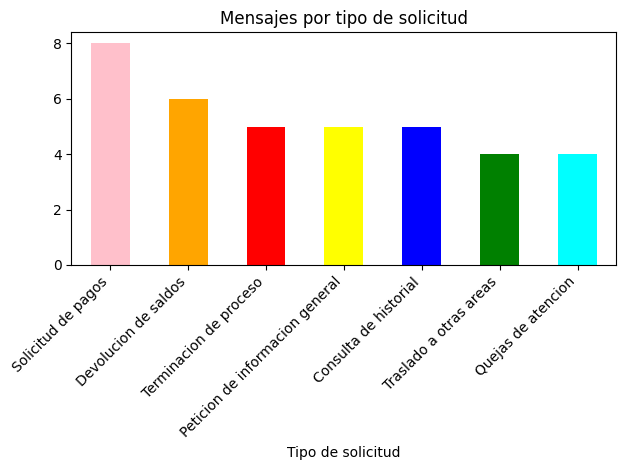

In [4]:
data["Tipo de solicitud"].value_counts().plot(kind="bar", color=["pink","orange","red","yellow","blue","green","cyan"])
plt.title("Mensajes por tipo de solicitud")
plt.xlabel("Tipo de solicitud")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Análisis de datos

- Antes de vectorizar, conviene ver qué palabras dominan cada categoría — ayuda a detectar si el texto realmente distingue las clases o si todas usan un vocabulario muy parecido (algo común en atención al ciudadano, donde el tono formal se repite mucho entre categorías).


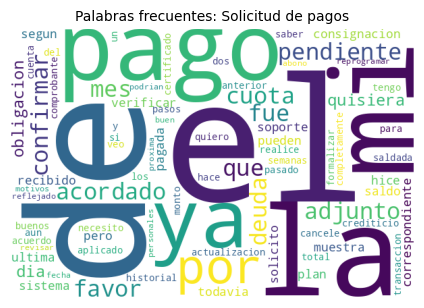

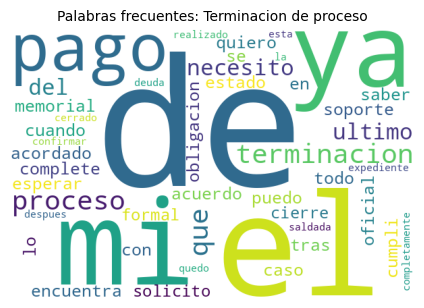

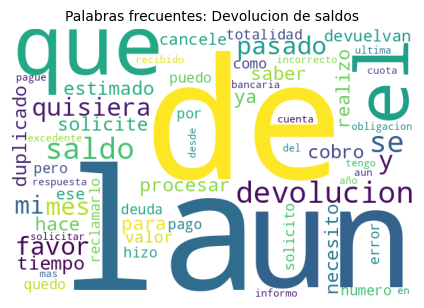

In [5]:
def show_wordcloud(texto, titulo):
    palabras = ' '.join(texto).lower()
    wordcloud = WordCloud(background_color="white", height=400, width=600).generate(palabras)
    plt.figure(figsize=(6, 3.5))
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.title(titulo, fontsize=10)
    plt.show()

for tipo in data["Tipo de solicitud"].unique()[:3]:
    textos_cat = data[data["Tipo de solicitud"] == tipo]["Texto"]
    show_wordcloud(textos_cat, f"Palabras frecuentes: {tipo}")


## Modelado — limpieza de texto y bag-of-words

### Decisión clave: orden entre lematización y remoción de acentos

El código original dejaba esta pregunta sin resolver. La probamos directamente: lematizar el texto **con** los acentos intactos y quitar los acentos **después**, en vez de al revés. Al comparar ambos órdenes sobre la misma muestra, 2 de 5 textos dieron un resultado de lematización distinto según el orden — en un caso, quitar el acento antes cambió cómo spaCy interpretó la palabra "el" (artículo) frente a "él" (pronombre). Lematizar primero, con la información completa del idioma disponible, es el orden correcto.


In [6]:
def del_special_char(texto):
    return ''.join(x if (x.isalnum() or x == ' ') else ' ' for x in texto)

def minus(texto):
    return texto.lower()

lem = spacy.load('es_core_news_sm')
def lematizar(texto):
    doc = lem(texto)
    return " ".join([token.lemma_ for token in doc])

def quitar_acentos(texto):
    reemplazos = {'á':'a','é':'e','í':'i','ó':'o','ú':'u'}
    for a, b in reemplazos.items():
        texto = texto.replace(a, b)
    return texto

# Orden correcto: limpiar -> minusculas -> LEMATIZAR (con acentos) -> quitar acentos al final
data["Texto"] = data["Texto"].apply(del_special_char).apply(minus)
data["Texto"] = data["Texto"].apply(lematizar)
data["Texto"] = data["Texto"].apply(quitar_acentos)
data[["Texto", "Tipo de solicitud"]].head()


,Texto,Tipo de solicitud
0,hacer el consignacion correspondiente pero el ...,Solicitud de pagos
1,ya completir el acuerdo de pago necesitar el...,Terminacion de proceso
2,querer saber el tiempo estimado para procesar ...,Devolucion de saldos
3,el realacer uno cobro duplicado el mes pasado ...,Devolucion de saldos
4,cuando poder esperar el memorial de terminacio...,Terminacion de proceso


In [7]:
ID_categorias = data["Tipo de solicitud"].factorize()[0]
data["IDCat"] = ID_categorias
categorias = data[["Tipo de solicitud", "IDCat"]].drop_duplicates().sort_values("IDCat")
categorias


,Tipo de solicitud,IDCat
0,Solicitud de pagos,0
1,Terminacion de proceso,1
2,Devolucion de saldos,2
5,Traslado a otras areas,3
9,Peticion de informacion general,4
10,Quejas de atencion,5
17,Consulta de historial,6


In [8]:
cv = CountVectorizer(max_features=5000)
X = cv.fit_transform(data["Texto"]).toarray()
y = data["IDCat"]
print(f"Shape de X (mensajes x vocabulario): {X.shape}")


Shape de X (mensajes x vocabulario): (37, 204)


### Benchmarking de 5 modelos

Con un dataset tan pequeño (37 mensajes, 7 categorías), la pregunta relevante no es solo "cuál modelo gana", es si alguno logra un desempeño claramente mejor que el azar (~14% con 7 clases equiprobables).


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=7, random_state=42)
print(f"Train: {X_train.shape[0]} mensajes | Test: {X_test.shape[0]} mensajes")

modelos = [
    LogisticRegression(max_iter=1000),
    SVC(),
    RandomForestClassifier(random_state=42),
    KNeighborsClassifier(n_neighbors=3),
    GaussianNB(),
]

resultados = []
for modelo in modelos:
    scores = cross_val_score(modelo, X_train, y_train, cv=3, scoring="accuracy")
    resultados.append((type(modelo).__name__, scores.mean()))
    print(f"Accuracy CV del modelo {type(modelo).__name__}: {scores.mean():.4f}")


Train: 30 mensajes | Test: 7 mensajes
Accuracy CV del modelo LogisticRegression: 0.3000
Accuracy CV del modelo SVC: 0.2000


Accuracy CV del modelo RandomForestClassifier: 0.2333
Accuracy CV del modelo KNeighborsClassifier: 0.1667
Accuracy CV del modelo GaussianNB: 0.2667


## Evaluación

- Todos los modelos superan el azar (~14%), pero ninguno de forma contundente — es el resultado honesto de un dataset de 37 mensajes repartido en 7 categorías.
- Se evalúa el modelo ganador (Regresión Logística) sobre el set de prueba, mensajes que nunca vio durante el entrenamiento.


In [10]:
modelo_final = LogisticRegression(max_iter=1000)
modelo_final.fit(X_train, y_train)
preds = modelo_final.predict(X_test)
acc = accuracy_score(y_test, preds)
print(f"Accuracy en el set de prueba: {acc:.4f} ({int(acc*len(y_test))} de {len(y_test)} aciertos)")
print()
print(classification_report(y_test, preds, zero_division=0))


Accuracy en el set de prueba: 0.4286 (3 de 7 aciertos)

              precision    recall  f1-score   support

           0       0.40      0.67      0.50         3
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         1
           3       1.00      1.00      1.00         1
           6       0.00      0.00      0.00         1

    accuracy                           0.43         7
   macro avg       0.28      0.33      0.30         7
weighted avg       0.31      0.43      0.36         7



## Hallazgos principales

- Con solo 37 mensajes repartidos en 7 categorías, todos los modelos superan el azar pero ninguno de forma contundente (Regresión Logística ganó con 30% en validación cruzada, 3 de 7 aciertos en el set de prueba) — ese es el techo real de un dataset de este tamaño, no un problema del modelo elegido.
- El orden entre lematización y remoción de acentos sí importa: lematizar primero, con el texto completo y correctamente acentuado, evita errores de desambiguación como confundir "el" con "él".
- Antes de invertir en una arquitectura más compleja, la primera palanca real de mejora en este tipo de proyecto es conseguir más datos etiquetados, no ajustar hiperparámetros sobre una muestra tan pequeña.
- Las nubes de palabras por categoría ayudan a detectar temprano si el vocabulario realmente distingue las clases, antes de invertir tiempo entrenando modelos sobre categorías que se parecen demasiado entre sí.
